<a href="https://colab.research.google.com/github/OMSCGR/Diagnostico-libadores-README.md/blob/main/libadores_quiebre_estructural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quiebre estructural en el registro de libadores — Quito, 2022-2026

**Observatorio Metropolitano de Seguridad Ciudadana y Gestión de Riesgos (OMSCGR)**

Base: panel de hexágonos de 300 m (`Hex_300m_Libadores_2022_2026Jun.xlsx`), enero 2022 a junio 2026.

Este notebook replica el análisis completo:

1. Carga y conciliación de la base.
2. Construcción de la serie mensual agregada.
3. Detección de quiebre estructural (`ruptures`, método PELT / Dynp).
4. Regresión de series de tiempo interrumpidas (ITS) con errores robustos HAC.
5. Comparación YTD (periodo comparable enero-junio).
6. Concentración territorial (barrios) y zonal (administraciones zonales) del salto post-quiebre.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

!pip install ruptures
import ruptures as rpt

pd.set_option('display.width', 120)
plt.rcParams.update({
    'figure.figsize': (11, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titleweight': 'bold',
})


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00


## 1. Carga de datos

Se usa el engine `calamine` (más rápido que `openpyxl` para ~1M filas). Si no está instalado:
`pip install python-calamine --break-system-packages`


In [6]:
!pip install python-calamine
RUTA = '/content/Hex_300m_Libadores_2022_2026Jun.xlsx'

df = pd.read_excel(RUTA, engine='openpyxl')
print(f"Filas brutas: {len(df):,}")
print(f"Hexágonos únicos: {df['Input_FID'].nunique():,}")
df.head()


Filas brutas: 1,006,560
Hexágonos únicos: 18,640


,OBJECTID,Input_FID,dpa_barrio,Nombre_Bar,Cod_Barrio,Parroquia,Cod_Parroq,Admin_Zona,AÑO,MES,LIBADOR
0,1,16321,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2022,Ene,0
1,2,16322,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2022,Ene,0
2,3,15724,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2022,Ene,0
3,4,15225,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2022,Ene,0
4,5,15425,170166001,CHIRIBOGA,EA_170166001,LLOA,170166,ELOY ALFARO,2022,Ene,0


## 2. Conciliación

El panel es un cruce completo hexágono × mes (sin buffers acumulativos ni deduplicación de incidentes:
cada fila ya es única). La conciliación es directa: filas brutas → suma de la columna `LIBADOR`.


In [7]:
meses = {'Ene':1,'Feb':2,'Mar':3,'Abr':4,'May':5,'Jun':6,
         'Jul':7,'Ago':8,'Sep':9,'Oct':10,'Nov':11,'Dic':12}
df['mes_num'] = df['MES'].map(meses)
df['fecha'] = pd.to_datetime(dict(year=df['AÑO'], month=df['mes_num'], day=1))

n_hex = df['Input_FID'].nunique()
n_meses = df['fecha'].nunique()
print(f"Filas brutas: {len(df):,} = {n_hex:,} hexágonos x {n_meses} meses -> {n_hex*n_meses:,}")
print(f"Total de registros de libador (2022-2026 jun): {df['LIBADOR'].sum():,}")


Filas brutas: 1,006,560 = 18,640 hexágonos x 54 meses -> 1,006,560
Total de registros de libador (2022-2026 jun): 226,493


## 3. Serie mensual agregada

In [8]:
monthly = (
    df.groupby('fecha')['LIBADOR']
      .agg(total='sum', promedio='mean')
      .reset_index()
      .sort_values('fecha')
      .reset_index(drop=True)
)
hex_activos = (
    df[df['LIBADOR'] > 0]
      .groupby('fecha')['Input_FID']
      .nunique()
      .reset_index(name='hexagonos_activos')
)
monthly = monthly.merge(hex_activos, on='fecha', how='left')
monthly['t'] = np.arange(len(monthly))
monthly


,fecha,total,promedio,hexagonos_activos,t
0,2022-01-01,5083,0.272693,904,0
1,2022-02-01,4444,0.238412,904,1
2,2022-03-01,6086,0.326502,892,2
3,2022-04-01,5084,0.272747,865,3
4,2022-05-01,5080,0.272532,861,4
5,2022-06-01,3745,0.200912,787,5
6,2022-07-01,4871,0.261320,866,6
7,2022-08-01,3920,0.210300,777,7
8,2022-09-01,4537,0.243401,820,8
9,2022-10-01,4492,0.240987,858,9


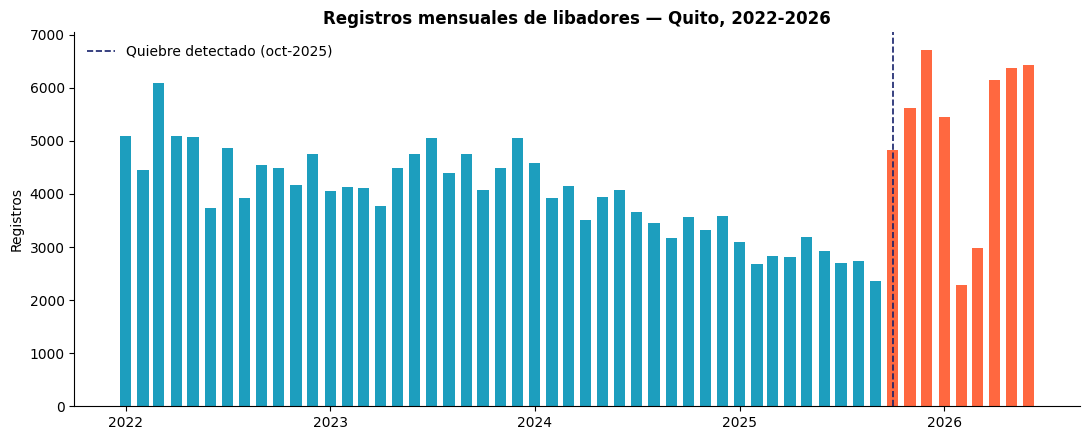

In [9]:
fig, ax = plt.subplots()
ax.bar(monthly['fecha'], monthly['total'], width=20,
       color=np.where(monthly['fecha'] >= '2025-10-01', '#ff6840', '#1d9ebe'))
ax.axvline(pd.Timestamp('2025-10-01'), color='#15206b', ls='--', lw=1.2, label='Quiebre detectado (oct-2025)')
ax.set_title('Registros mensuales de libadores — Quito, 2022-2026')
ax.set_ylabel('Registros')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 4. Detección de quiebre estructural

Se usa `ruptures` con el algoritmo exacto `Dynp` (minimiza el error cuadrático) fijando distintos
números de quiebres, y `Pelt` (penalizado) para una selección automática del número óptimo.


In [10]:
y = monthly['total'].values.astype(float)

# Selección automática del número de quiebres (penalizado)
algo_pelt = rpt.Pelt(model="rbf").fit(y)
bkps_pelt = algo_pelt.predict(pen=5)
print("PELT (automático):")
for b in bkps_pelt:
    print(" ->", monthly['fecha'].iloc[b].date() if b < len(monthly) else "fin de serie")

# Número fijo de quiebres (para comparar robustez)
algo_dynp = rpt.Dynp(model="l2").fit(y)
for k in [1, 2, 3]:
    bk = algo_dynp.predict(n_bkps=k)
    fechas = [str(monthly['fecha'].iloc[b].date()) if b < len(monthly) else 'fin' for b in bk]
    print(f"Dynp, {k} quiebre(s) -> {fechas}")


PELT (automático):
 -> 2024-07-01
 -> fin de serie
Dynp, 1 quiebre(s) -> ['2025-10-01', 'fin']
Dynp, 2 quiebre(s) -> ['2024-07-01', '2025-10-01', 'fin']
Dynp, 3 quiebre(s) -> ['2022-06-01', '2024-07-01', '2025-10-01', 'fin']


**Resultado:** el quiebre dominante se ubica de forma consistente en **octubre de 2025**
(con un quiebre secundario, de aceleración de la caída previa, en julio de 2024).

## 5. Regresión de series de tiempo interrumpidas (ITS)

Especificación estándar de ITS con quiebre en `T0 = 2025-10`:

$$Y_t = \beta_0 + \beta_1 \cdot t + \beta_2 \cdot D_t + \beta_3 \cdot (t - T_0)\cdot D_t + \varepsilon_t$$

donde $D_t = 1$ si $t \geq T_0$. $\beta_2$ captura el **salto de nivel** en $T_0$;
$\beta_3$ captura el **cambio de pendiente** posterior. Errores estándar robustos a
heterocedasticidad y autocorrelación (HAC, Newey-West, 3 rezagos).


In [11]:
T0 = pd.Timestamp('2025-10-01')
monthly['D'] = (monthly['fecha'] >= T0).astype(int)
t0_idx = monthly.loc[monthly['fecha'] == T0, 't'].values[0]
monthly['t_since'] = np.where(monthly['D'] == 1, monthly['t'] - t0_idx, 0)

X = sm.add_constant(monthly[['t', 'D', 't_since']])
its_model = sm.OLS(monthly['total'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
print(its_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  total   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     33.10
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           6.24e-12
Time:                        16:01:24   Log-Likelihood:                -432.81
No. Observations:                  54   AIC:                             873.6
Df Residuals:                      50   BIC:                             881.6
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5128.6850    165.224     31.041      0.0

**Lectura:** la tendencia previa es negativa y significativa (~ -52 registros/mes).
El salto de nivel en octubre-2025 es positivo y significativo (~ +2.064 registros, p ≈ 0,002).
El cambio de pendiente posterior **no** es significativo — el quiebre es principalmente un
**salto de nivel (escalón)**, no una aceleración gradual de la tendencia.

### Regresiones por segmento (robustez)

Se estima la pendiente OLS dentro de cada tramo delimitado por los quiebres detectados.


In [12]:
segmentos = [
    ("2022-01 a 2024-06", '2022-01-01', '2024-06-01'),
    ("2024-07 a 2025-09", '2024-07-01', '2025-09-01'),
    ("2025-10 a 2026-06", '2025-10-01', '2026-06-01'),
]

resumen = []
for nombre, ini, fin in segmentos:
    seg = monthly[(monthly['fecha'] >= ini) & (monthly['fecha'] <= fin)]
    Xs = sm.add_constant(seg['t'])
    m = sm.OLS(seg['total'], Xs).fit()
    resumen.append({
        'segmento': nombre, 'n_meses': len(seg),
        'pendiente_mes': round(m.params['t'], 1), 'p_valor': round(m.pvalues['t'], 4),
        'inicio': int(seg['total'].iloc[0]), 'fin': int(seg['total'].iloc[-1]),
        'var_pct': round((seg['total'].iloc[-1] / seg['total'].iloc[0] - 1) * 100, 1),
    })

pd.DataFrame(resumen)


,segmento,n_meses,pendiente_mes,p_valor,inicio,fin,var_pct
0,2022-01 a 2024-06,30,-26.9,0.0161,5083,4072,-19.9
1,2024-07 a 2025-09,15,-73.4,0.0001,3652,2368,-35.2
2,2025-10 a 2026-06,9,83.7,0.7084,4836,6425,32.9


## 6. Comparación YTD (periodo comparable enero-junio)

In [13]:
ytd = df[df['mes_num'] <= 6].groupby('AÑO')['LIBADOR'].sum()
promedio_2022_2025 = ytd.loc[2022:2025].mean()
var_ytd = (ytd.loc[2026] / promedio_2022_2025 - 1) * 100

display(ytd.rename('registros_ene_jun').to_frame())
print(f"\nPromedio comparable 2022-2025: {promedio_2022_2025:,.0f}")
print(f"2026 (ene-jun): {ytd.loc[2026]:,} -> variación: {var_ytd:+.1f}%")


,registros_ene_jun
AÑO,
2022,29522
2023,25338
2024,24158
2025,17519
2026,29666



Promedio comparable 2022-2025: 24,134
2026 (ene-jun): 29,666 -> variación: +22.9%


## 7. Concentración territorial: barrios que más explican el salto

Comparación de 9 meses antes del quiebre (enero-septiembre 2025) vs. 9 meses después
(octubre 2025-junio 2026).


In [14]:
PRE_INI, PRE_FIN = '2025-01-01', '2025-09-01'
POST_INI, POST_FIN = '2025-10-01', '2026-06-01'

pre_b = df[(df.fecha >= PRE_INI) & (df.fecha <= PRE_FIN)].groupby('Nombre_Bar')['LIBADOR'].sum()
post_b = df[(df.fecha >= POST_INI) & (df.fecha <= POST_FIN)].groupby('Nombre_Bar')['LIBADOR'].sum()

barrios = pd.DataFrame({'pre': pre_b, 'post': post_b}).fillna(0)
barrios['delta'] = barrios['post'] - barrios['pre']
barrios['var_pct'] = (barrios['post'] / barrios['pre'].replace(0, np.nan) - 1) * 100
top10 = barrios.sort_values('delta', ascending=False).head(10)

share_top10 = top10['delta'].sum() / barrios['delta'].sum() * 100
print(f"Los 10 barrios de mayor incremento concentran el {share_top10:.1f}% del salto total del Distrito.\n")
top10.round(1)


Los 10 barrios de mayor incremento concentran el 20.1% del salto total del Distrito.



,pre,post,delta,var_pct
Nombre_Bar,,,,
LA FLORESTA (MARISCAL SUCRE),794,1863,1069,134.6
PLACER ALTO,227,778,551,242.7
CIUDADELA UNIVERSITARIA,462,954,492,106.5
COMITÉ DEL PUEBLO,293,678,385,131.4
LA MAGDALENA CENTRAL,288,602,314,109.0
MARISCAL SUCRE,397,711,314,79.1
GONZÁLEZ SUÁREZ,253,564,311,122.9
BARRIO UNIÓN Y JUSTICIA,202,505,303,150.0
SIERRA HERMOSA,352,651,299,84.9


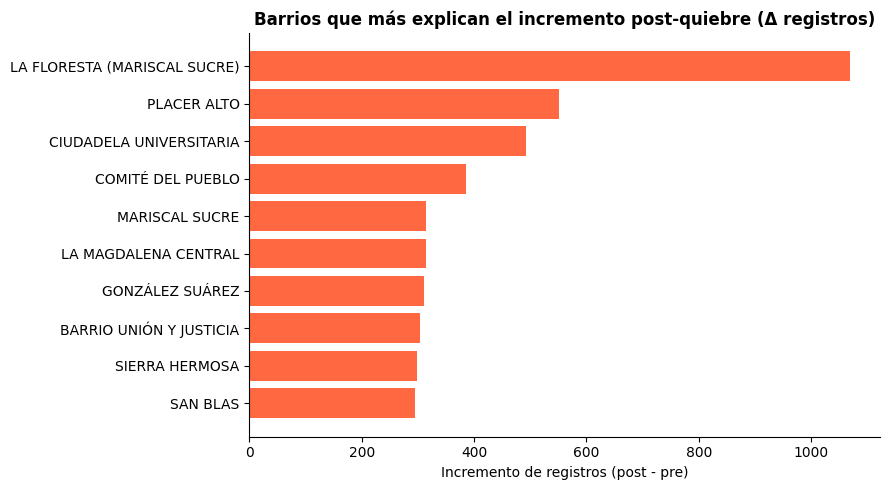

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
top10_sorted = top10.sort_values('delta')
ax.barh(top10_sorted.index, top10_sorted['delta'], color='#ff6840')
ax.set_title('Barrios que más explican el incremento post-quiebre (Δ registros)')
ax.set_xlabel('Incremento de registros (post - pre)')
plt.tight_layout()
plt.show()


## 8. Concentración por zona administrativa

In [16]:
pre_z = df[(df.fecha >= PRE_INI) & (df.fecha <= PRE_FIN)].groupby('Admin_Zona')['LIBADOR'].sum()
post_z = df[(df.fecha >= POST_INI) & (df.fecha <= POST_FIN)].groupby('Admin_Zona')['LIBADOR'].sum()

zonas = pd.DataFrame({'pre': pre_z, 'post': post_z}).fillna(0)
zonas['delta'] = zonas['post'] - zonas['pre']
zonas['var_pct'] = (zonas['post'] / zonas['pre'].replace(0, np.nan) - 1) * 100
zonas = zonas.sort_values('post', ascending=False)

n_en_alza = (zonas['delta'] > 0).sum()
print(f"{n_en_alza} de {len(zonas)} administraciones zonales registran incremento post-quiebre.\n")
zonas.round(1)


10 de 10 administraciones zonales registran incremento post-quiebre.



,pre,post,delta,var_pct
Admin_Zona,,,,
ELOY ALFARO,5495,11102,5607,102.0
MANUELA SÁENZ,3750,7241,3491,93.1
LA DELICIA,3301,6047,2746,83.2
EUGENIO ESPEJO,3166,5895,2729,86.2
QUITUMBE,2919,4898,1979,67.8
LA MARISCAL,2316,4795,2479,107.0
CALDERÓN,1409,2615,1206,85.6
TUMBACO,1623,2137,514,31.7
LOS CHILLOS,1141,1878,737,64.6


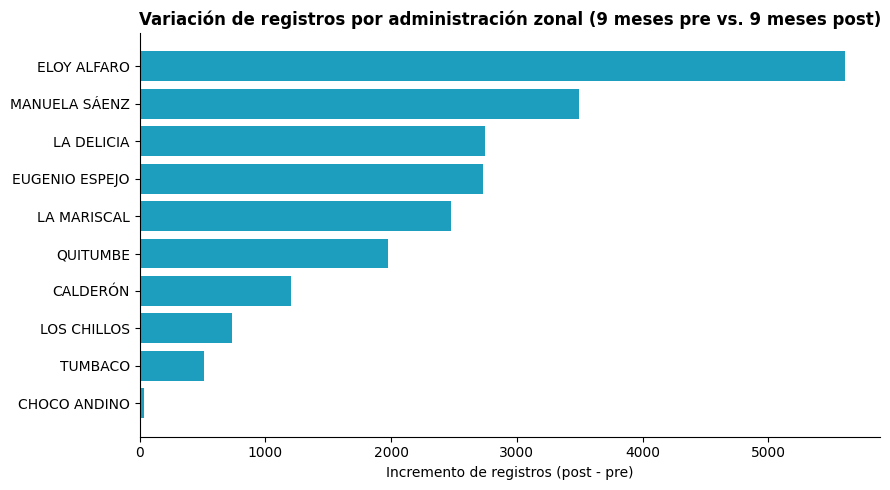

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
zonas_sorted = zonas.sort_values('delta')
ax.barh(zonas_sorted.index, zonas_sorted['delta'], color='#1d9ebe')
ax.set_title('Variación de registros por administración zonal (9 meses pre vs. 9 meses post)')
ax.set_xlabel('Incremento de registros (post - pre)')
plt.tight_layout()
plt.show()


## 9. Conclusiones

- El registro de libadores en Quito no sigue una tendencia única: hay una **fase de declive
  sostenido** (ene-2022 a sep-2025, que se acelera desde jul-2024) seguida de un **quiebre
  estructural en octubre de 2025**.
- El quiebre es, formalmente, un **salto de nivel** (β₂ significativo, p ≈ 0,002) y no un
  cambio gradual de pendiente (β₃ no significativo) — la ITS lo confirma.
- El primer semestre de 2026 se ubica **+22,9%** por encima del promedio comparable
  2022-2025, revirtiendo el mínimo histórico alcanzado en 2025.
- El salto es de **escala distrital**: las 10 administraciones zonales muestran incremento,
  aunque con intensidades distintas (Eloy Alfaro y La Mariscal a la cabeza).
- Territorialmente, el crecimiento tiene una presencia notoria en entornos de vida nocturna
  y universitaria (La Floresta/Mariscal Sucre, Ciudadela Universitaria), aunque estos 10
  barrios solo explican ~20% del salto total — el fenómeno es mayormente transversal.
- **Próximo paso sugerido:** validar el quiebre de octubre-2025 contra información operativa
  (cambios de protocolo de registro, despliegue de patrullaje, calendario de eventos/vida
  nocturna) para distinguir entre un cambio real de comportamiento y un cambio de medición.
